In [1]:
import utils
import keras
import numpy as np
import matplotlib.pyplot as plt

2026-02-21 15:50:10.865099: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 15:50:11.719949: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 15:50:21.287425: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
columns = ("model", "lighting", "year")
other = 'Other car'

In [3]:
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=columns, strata_threshold=38)

../datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
../datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
../datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
../datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg


In [4]:

vt = np.vectorize(lambda x: 1 if x else 0)

train_y_gate1 = train_y["model"] == 'Other car'
train_y_gate1 = vt(train_y_gate1)
test_y_gate1 = test_y["model"] == 'Other car'
test_y_gate1 = vt(test_y_gate1)

input_shape = train_x[0].shape
num_classes = 1


def model_to_int(model):
    dict = {'S': 0, '3': 1, 'X':2, 'Y': 3}
    return dict[model]


train_y_gate2 = train_y["model"][train_y["model"] != other]
train_y_gate2 = np.vectorize(model_to_int)(train_y_gate2)

train_x_gate2 = train_x[train_y["model"] != other]

test_y_gate2 = test_y["model"][test_y["model"] != other]
test_y_gate2 = np.vectorize(model_to_int)(test_y_gate2)

test_x_gate2 = test_x[test_y["model"] != other]

input_shape = train_x[0].shape

In [5]:
i = 0

1


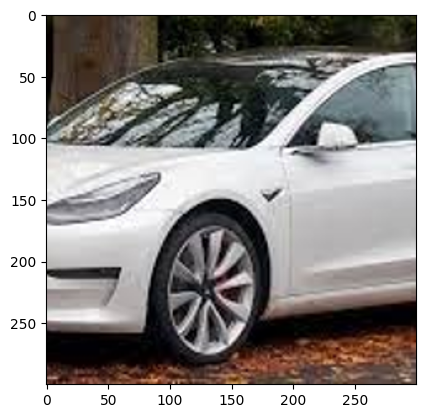

In [6]:
print(train_y_gate2[i])
plt.imshow(train_x_gate2[i])
i += 1

In [7]:
def get_feature_extractor(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    return keras.Model(inputs, x, name="extractor")

feature_extractor = get_feature_extractor(input_shape=input_shape)

input_gate1 = keras.Input(shape=input_shape)
x = feature_extractor(input_gate1)
outputs_gate1 = keras.layers.Dense(1, activation="sigmoid")(x)
model_a = keras.Model(input_gate1, outputs_gate1)

input_gate2 = keras.Input(shape=input_shape)
x = feature_extractor(input_gate2)
output_gate2 = keras.layers.Dense(4, activation="softmax")(x)
model_b = keras.Model(input_gate2, output_gate2)

model_a.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model_b.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_a.fit(train_x, train_y_gate1, epochs=10, batch_size=16)
print(model_a.evaluate(test_x, test_y_gate1))
model_b.fit(train_x_gate2, train_y_gate2, epochs=10, batch_size=16)



I0000 00:00:1771685467.392635   12054 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


2026-02-21 15:51:17.075247: I external/local_xla/xla/service/service.cc:163] XLA service 0x71d390006980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-21 15:51:17.075281: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-21 15:51:17.218724: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-21 15:51:17.675333: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  3/232 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4757 - loss: 0.6961 

I0000 00:00:1771685482.609606   12426 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.6945 - loss: 0.5809
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7807 - loss: 0.4778
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7963 - loss: 0.4492
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8217 - loss: 0.4043
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8379 - loss: 0.3753
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8466 - loss: 0.3438
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8668 - loss: 0.3134
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8871 - loss: 0.2709
Epoch 9/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8968 - loss: 0.2465
Epoch 10/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9087 - loss: 0.2251
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8373 - loss: 0.3920
[0.39195483922958374, 0.8372827768325806]
Epoch 1/10
123/123 ━━━━

In [ ]:

print(model_a.evaluate(test_x, test_y_gate1))
print(model_b.evaluate(test_x_gate2, test_y_gate2))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8041 - loss: 0.6899
[0.689873993396759, 0.8041074275970459]


2026-02-21 15:53:07.280741: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_124', 8 bytes spill stores, 8 bytes spill loads

2026-02-21 15:53:07.282978: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_124', 8 bytes spill stores, 8 bytes spill loads



11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5908 - loss: 1.4256
[1.4256324768066406, 0.5907692313194275]


In [15]:
i = 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[0.23156509]]


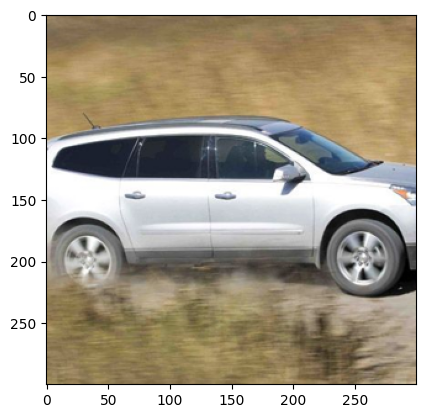

In [ ]:
error = False
while(not error):
    pred = model_a.predict(np.expand_dims(test_x[i], axis=0))
    error = test_y_gate1[i] > 0.5 and pred < 0.5
    i += 1
print(pred)
plt.imshow(test_x[i-1])